# Task 1 — Interpreting Correlations (Insurance Dataset)

**Question:** Which factors are associated with higher medical insurance expenses?

**Data:** Kaggle `noordeen/insurance-premium-prediction` — the same `insurance.csv` used by `01_simple_linear.py` and the linear regression lab (1,338 people).

| Column | Type | Meaning |
|---|---|---|
| age | Numeric | Age in years |
| bmi | Numeric | Body Mass Index |
| children | Numeric | Number of dependents covered |
| expenses | Numeric (**target**) | Yearly medical insurance charges (USD) |
| sex | Categorical — binary | female / male |
| smoker | Categorical — binary | no / yes |
| region | Categorical — 4 levels | northeast / northwest / southeast / southwest |

**Roadmap:** 5-row mini dataset → transform categories → compute r by hand → why 5 rows aren't enough → full data → connect to `01_simple_linear.py` → bridge to regression → your turn

> Setup: follow **README.md** (create `.venv`, activate it, `pip install -r requirements.txt`), then choose `.venv` as the kernel (top-right **Select Kernel**).

In [1]:
from pathlib import Path
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 30)

def resolve_csv_path() -> Path:
    # Same location 01_simple_linear.py uses; download with kagglehub if missing.
    project_csv = Path.cwd() / "data" / "insurance-premium-prediction" / "insurance.csv"
    if project_csv.exists():
        return project_csv
    import kagglehub
    cached_dir = Path(kagglehub.dataset_download("noordeen/insurance-premium-prediction"))
    return cached_dir / "insurance.csv"

csv_path = resolve_csv_path()
df = pd.read_csv(csv_path)
print("Loaded:", csv_path.name, "from", csv_path.parent.name)
print("Shape:", df.shape)

c:\Users\60940\msba265\Linear-Regression-Concepts\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded: insurance.csv from 1
Shape: (1338, 7)


In [2]:
# The strength labels used everywhere in this notebook (same as 01_simple_linear.py)
def strength_label(r):
    a = abs(r)
    if a < 0.10: return "very weak"
    if a < 0.30: return "weak"
    if a < 0.50: return "moderate"
    if a < 0.70: return "strong"
    return "very strong"

def direction_label(r):
    return "positive" if r > 0 else "negative" if r < 0 else "no linear"

## Step 1 — The 5-row mini dataset

Five rows, three types of data: **numeric**, **binary categorical**, and **multi-category**.

In [3]:
mini = df.head(5).copy()
mini

,age,sex,bmi,children,smoker,region,expenses
0,19,female,27.9,0,yes,southwest,16884.92
1,18,male,33.8,1,no,southeast,1725.55
2,28,male,33.0,3,no,southeast,4449.46
3,33,male,22.7,0,no,northwest,21984.47
4,32,male,28.9,0,no,northwest,3866.86


Correlation is arithmetic, and you can't do arithmetic on the word `"yes"`. So before computing anything, the categorical columns need to become numbers — **the right way**.

## Step 2 — Transforming categorical data

### 2a. Binary categories → 0 / 1

`smoker` and `sex` each have exactly two values, so we map them to 0 and 1.
Pearson correlation between a 0/1 column and a numeric column is called the **point-biserial correlation** — same formula, no new math.

In [4]:
mini["smoker_encoded"] = mini["smoker"].map({"no": 0, "yes": 1})
mini["sex_encoded"] = mini["sex"].map({"female": 0, "male": 1})
mini[["smoker", "smoker_encoded", "sex", "sex_encoded"]]

,smoker,smoker_encoded,sex,sex_encoded
0,yes,1,female,0
1,no,0,male,1
2,no,0,male,1
3,no,0,male,1
4,no,0,male,1


### 2b. Multi-category → one-hot, **never** 1, 2, 3, 4

`region` has 4 values. Coding northeast = 1, northwest = 2, southeast = 3, southwest = 4 would pretend that:
- regions have a meaningful **order**, and
- the **gaps are equal** (southwest − southeast = northwest − northeast).

Neither is true. Instead, **one-hot encoding** makes one 0/1 column per region:

In [5]:
region_dummies = pd.get_dummies(mini["region"], prefix="region", dtype=int)
pd.concat([mini[["region"]], region_dummies], axis=1)

,region,region_northwest,region_southeast,region_southwest
0,southwest,0,0,1
1,southeast,0,1,0
2,southeast,0,1,0
3,northwest,1,0,0
4,northwest,1,0,0


Proof that 1-2-3-4 coding is meaningless: two equally arbitrary orders give **different** answers on the same data.

In [6]:
order_a = {"northeast": 1, "northwest": 2, "southeast": 3, "southwest": 4}
order_b = {"southeast": 1, "northeast": 2, "southwest": 3, "northwest": 4}

r_a = df["region"].map(order_a).corr(df["expenses"])
r_b = df["region"].map(order_b).corr(df["expenses"])
print(f"Coding A: r = {r_a:.3f}")
print(f"Coding B: r = {r_b:.3f}")
print("Same data, different made-up numbers, different r -> the number means nothing.")

Coding A: r = -0.006
Coding B: r = -0.076
Same data, different made-up numbers, different r -> the number means nothing.


## Step 3 — Computing Pearson r by hand (age vs expenses, 5 rows)

$$
r = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum (x_i - \bar{x})^2 \;\sum (y_i - \bar{y})^2}}
$$

1. Subtract the mean from every value (the "deviation").
2. Multiply each row's x-deviation by its y-deviation. Same side of the mean → positive product.
3. Add the products, then divide by the scaling term so r lands between −1 and +1.

In [7]:
x = mini["age"].astype(float)
y = mini["expenses"]

work = pd.DataFrame({"age (x)": x, "expenses (y)": y})
work["x - x_bar"] = x - x.mean()
work["y - y_bar"] = y - y.mean()
work["product"] = work["x - x_bar"] * work["y - y_bar"]
work["(x - x_bar)^2"] = work["x - x_bar"] ** 2
work["(y - y_bar)^2"] = work["y - y_bar"] ** 2

print(f"x_bar = {x.mean():.2f}    y_bar = {y.mean():,.2f}")
work.round(2)

x_bar = 26.00    y_bar = 9,782.25


,age (x),expenses (y),x - x_bar,y - y_bar,product,(x - x_bar)^2,(y - y_bar)^2
0,19.0,16884.92,-7.0,7102.67,-49718.68,49.0,5.044789e+07
1,18.0,1725.55,-8.0,-8056.70,64453.62,64.0,6.491045e+07
2,28.0,4449.46,2.0,-5332.79,-10665.58,4.0,2.843867e+07
3,33.0,21984.47,7.0,12202.22,85415.53,49.0,1.488941e+08
4,32.0,3866.86,6.0,-5915.39,-35492.35,36.0,3.499186e+07


In [8]:
numerator = work["product"].sum()
denominator = math.sqrt(work["(x - x_bar)^2"].sum() * work["(y - y_bar)^2"].sum())
r_by_hand = numerator / denominator

print(f"numerator   = {numerator:,.2f}")
print(f"denominator = {denominator:,.2f}")
print(f"r by hand   = {r_by_hand:.3f}  ({strength_label(r_by_hand)}, {direction_label(r_by_hand)})")
print(f"pandas check: {x.corr(y):.3f}")

numerator   = 53,992.53
denominator = 257,277.99
r by hand   = 0.210  (weak, positive)
pandas check: 0.210


## Step 4 — Why 5 rows are not enough

In [9]:
df["smoker_encoded"] = df["smoker"].map({"no": 0, "yes": 1})
df["sex_encoded"] = df["sex"].map({"female": 0, "male": 1})

compare = pd.DataFrame({
    "r (5 rows)": [df[c].head(5).corr(df["expenses"].head(5)) for c in ["age", "bmi", "smoker_encoded"]],
    f"r ({len(df)} rows)": [df[c].corr(df["expenses"]) for c in ["age", "bmi", "smoker_encoded"]],
}, index=["age", "bmi", "smoker (0/1)"])
compare.round(3)

,r (5 rows),r (1338 rows)
age,0.210,0.299
bmi,-0.892,0.199
smoker (0/1),0.439,0.787


**bmi flips sign**: strongly negative on 5 rows, weakly positive on all rows. Five rows are for learning the formula; conclusions need the full dataset.

## Step 5 — Full dataset: correlation matrix and interpretation

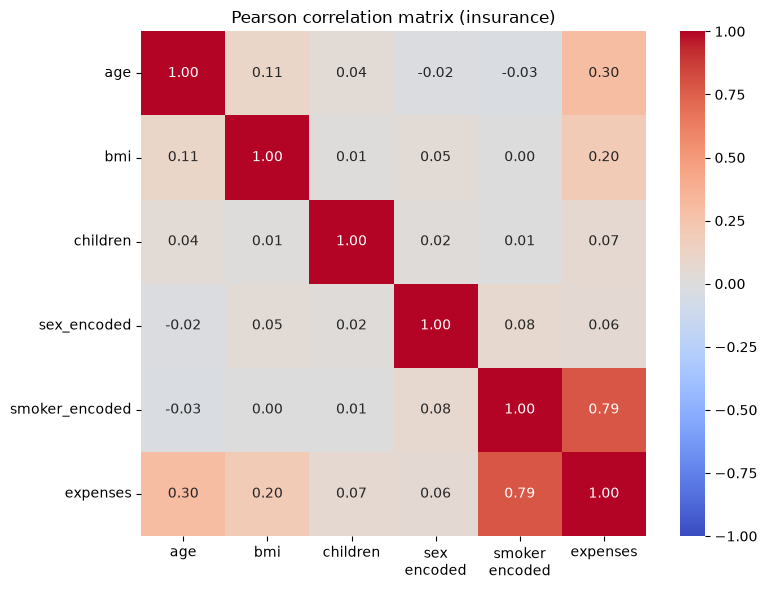

In [10]:
cols = ["age", "bmi", "children", "sex_encoded", "smoker_encoded", "expenses"]
corr = df[cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True, ax=ax)
ax.set_xticklabels([t.get_text().replace("_", "\n") for t in ax.get_xticklabels()], rotation=0)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
ax.set_title("Pearson correlation matrix (insurance)")
plt.tight_layout()
plt.show()

In [11]:
print("Correlation with expenses (strongest first):")
ranked = corr["expenses"].drop("expenses").sort_values(key=abs, ascending=False)
for feature, r in ranked.items():
    print(f"  {feature:15s} r = {r:+.3f}  -> {strength_label(r)}, {direction_label(r)}")

Correlation with expenses (strongest first):
  smoker_encoded  r = +0.787  -> very strong, positive
  age             r = +0.299  -> weak, positive
  bmi             r = +0.199  -> weak, positive
  children        r = +0.068  -> very weak, positive
  sex_encoded     r = +0.057  -> very weak, positive


In [12]:
# Check the smoker result with group averages
print(df.groupby("smoker")["expenses"].mean().round(2))

smoker
no      8434.27
yes    32050.23
Name: expenses, dtype: float64


**Interpretation:** `smoker` is the dominant factor (r ≈ 0.79, very strong). Smokers' average expenses are roughly 3.8 times those of non-smokers. `age` and `bmi` are weak; `children` and `sex` are very weak.

In [13]:
# region: one-hot correlations + eta (one overall number, 0 to 1)
dummies = pd.get_dummies(df["region"], prefix="region", dtype=int)
print("One-hot region columns vs expenses:")
print(pd.concat([dummies, df["expenses"]], axis=1).corr()["expenses"].drop("expenses").round(3))

def correlation_ratio(categories, values):
    data = pd.DataFrame({"cat": categories, "val": values})
    grand_mean = data["val"].mean()
    g = data.groupby("cat")["val"]
    ss_between = (g.count() * (g.mean() - grand_mean) ** 2).sum()
    ss_total = ((data["val"] - grand_mean) ** 2).sum()
    return math.sqrt(ss_between / ss_total)

eta = correlation_ratio(df["region"], df["expenses"])
print(f"\neta (region -> expenses) = {eta:.3f}  ({strength_label(eta)})")
print(df.groupby("region")["expenses"].mean().round(2))

One-hot region columns vs expenses:
region_northeast    0.006
region_northwest   -0.040
region_southeast    0.074
region_southwest   -0.043
Name: expenses, dtype: float64

eta (region -> expenses) = 0.081  (very weak)
region
northeast    13406.38
northwest    12417.58
southeast    14735.41
southwest    12346.94
Name: expenses, dtype: float64


| Data type | Transformation | Method |
|---|---|---|
| Numeric vs numeric | none | Pearson (linear) or Spearman (ranks) |
| Binary vs numeric | 0 / 1 | Pearson = point-biserial |
| Ordered categories vs numeric | ranks 1, 2, 3 | Spearman |
| Unordered multi-category vs numeric | one-hot | r per dummy, or eta |

## Step 6 — Connecting to `01_simple_linear.py`

The script computes Pearson r in plain Python (no pandas). It is exactly the Step 3 formula in code:

In [14]:
def pearson_correlation(x, y):          # copied from 01_simple_linear.py
    n = len(x)
    x_mean = sum(x) / n
    y_mean = sum(y) / n
    num = sum((xi - x_mean) * (yi - y_mean) for xi, yi in zip(x, y))
    den_x = math.sqrt(sum((xi - x_mean) ** 2 for xi in x))
    den_y = math.sqrt(sum((yi - y_mean) ** 2 for yi in y))
    if den_x == 0 or den_y == 0:
        return 0.0
    return num / (den_x * den_y)

for col in ["age", "bmi", "children"]:
    print(f"{col:10s} script: {pearson_correlation(df[col].tolist(), df['expenses'].tolist()):.4f}"
          f"   pandas: {df[col].corr(df['expenses']):.4f}")

print("\nOur extension (the script skips smoker):")
print(f"smoker     script: {pearson_correlation(df['smoker_encoded'].tolist(), df['expenses'].tolist()):.4f}")

age        script: 0.2990   pandas: 0.2990
bmi        script: 0.1986   pandas: 0.1986
children   script: 0.0680   pandas: 0.0680

Our extension (the script skips smoker):
smoker     script: 0.7873


## Step 7 — From correlation to regression

**Correlation says *if*; regression says *how much*.** In simple (one-feature) linear regression, **R² = r²**.

In [15]:
r_bmi = df["bmi"].corr(df["expenses"])
slope, intercept = np.polyfit(df["bmi"], df["expenses"], 1)
pred = intercept + slope * df["bmi"]
r2 = 1 - ((df["expenses"] - pred) ** 2).sum() / ((df["expenses"] - df["expenses"].mean()) ** 2).sum()

print(f"r (bmi, expenses) = {r_bmi:.4f}")
print(f"r squared         = {r_bmi**2:.4f}")
print(f"regression R^2    = {r2:.4f}   <- the same")
print(f"\nCorrelation: bmi and expenses are {strength_label(r_bmi)}ly related.")
print(f"Regression:  each +1 BMI -> about ${slope:,.0f} more predicted expenses.")
print(f"But bmi alone explains only {r2:.1%} of the variation in expenses.")

r (bmi, expenses) = 0.1986
r squared         = 0.0394
regression R^2    = 0.0394   <- the same

Correlation: bmi and expenses are weakly related.
Regression:  each +1 BMI -> about $394 more predicted expenses.
But bmi alone explains only 3.9% of the variation in expenses.


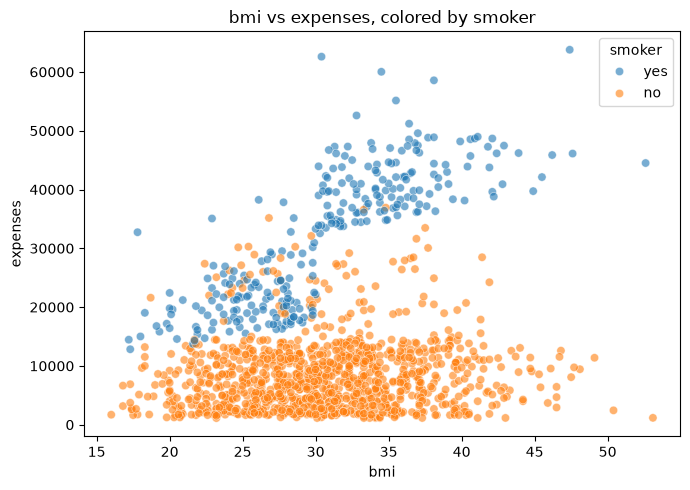

In [16]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(data=df, x="bmi", y="expenses", hue="smoker", alpha=0.6, ax=ax)
ax.set_title("bmi vs expenses, colored by smoker")
plt.tight_layout()
plt.show()

The picture explains the numbers: the **smoker / non-smoker split** separates the points far more than bmi does.

## Step 8 — Limits: what correlation doesn't tell you

- **Not causation.** Correlation shows association, not cause.
- **Linear only.** Pearson can miss curved or grouped patterns — always plot.
- **Skew and outliers.** `expenses` is right-skewed (a few very large bills). Compare Pearson with the rank-based Spearman:

In [17]:
for col in ["age", "bmi", "children", "smoker_encoded"]:
    p = df[col].corr(df["expenses"], method="pearson")
    s = df[col].corr(df["expenses"], method="spearman")
    print(f"{col:15s} Pearson {p:+.3f}   Spearman {s:+.3f}")

age             Pearson +0.299   Spearman +0.534
bmi             Pearson +0.199   Spearman +0.119
children        Pearson +0.068   Spearman +0.133
smoker_encoded  Pearson +0.787   Spearman +0.663


`age` jumps from 0.30 (Pearson) to 0.53 (Spearman): the steady age–expenses trend is partly hidden by the extreme smoker bills. When the two measures disagree, look closer.